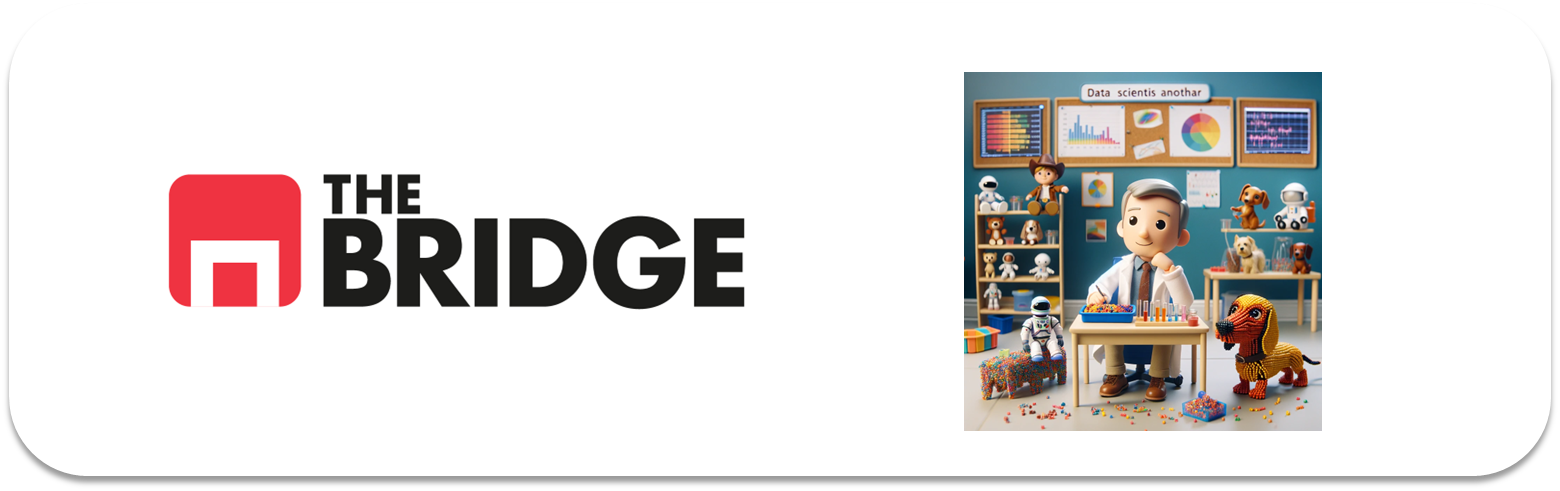

## PRACTICA OBLIGATORIA: ANÁLISIS UNIVARIANTE

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [4]:

import seaborn as sns



### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [5]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [6]:
df_titanic = sns.load_dataset('titanic')

In [7]:
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [8]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [10]:
df_titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [11]:
(df_titanic.isnull().sum() / len(df_titanic)) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [12]:
# En primer lugar, como vemos a simple vista los valores nulos en 'embarked' y en 'embark_town' son muy pocos, por lo que prescindir de las filas no causará un gran impacto en nuestro análisis.
df_titanic = df_titanic.dropna(subset=['embarked', 'embark_town'])

In [ ]:
# Imputamos la edad en función del tipo de pasajero ('who') y la clase en la que viajaba ('pclass').
df_titanic["age"] = df_titanic["age"].fillna(
    df_titanic.groupby(["who", "pclass"])["age"].transform("median")
)

In [14]:
# En cuanto a la cubierta, pudiendo sacrificar algo de limpieza en el dataset. He decidido conservar los valores nulos, como pertenecer a una cubierta desconocida. Opino que es una variable que puede aportar informacion relevante
df_titanic["deck"] = df_titanic["deck"].cat.add_categories("Unknown").fillna("Unknown")

In [15]:
df_titanic = df_titanic.drop(columns=["parch"])

In [16]:
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,Unknown,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,26.0,1,23.4500,S,Third,woman,False,Unknown,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [17]:
df_titanic["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| Survived(1, 0)   | Refleja si el pasajero sobrevivió (1) o no (0) |
| Pclass (1, 2, 3) | Refleja la clase en la que viajaba el pasajero |
| Sex (M, F) | Refleja el sexo del pasajero |
| Age (0.42 -> 80.00) | Refleja la edad del pasajero |
| Sibsp (0 -> 8) | Refleja el numero de familiares que viajaban con el pasajero |
| Fare (0 -> 512.3292) | Refleja el precio que pago el pasajero por el billete |
| Embarked (S, C, Q) | Refleja la inicial de la ciudad de embarque |
| Class (1ª, 2ª, 3ª) | Refleja la clase en la que viajaba el pasajero |
| Who (M, F, C) | Refleja el sexo del pasajero o si era niño |
| Adult Male (True, False) | Refleja si el pasajero es un hombre adulto |
| Deck (A -> G, "Unknown") | Refleja la cubierta donde se alojaba el pasajero |
| Embark_Town (Southampton, Cherbourg, Queenstown) | Refleja el nombre completo de la ciudad de embarque |
| Alive (Yes, No) | Refleja si el pasajero sobrevivio |
| Alone (True, False) | Refleja si el pasajero viajaba solo o acompañado |


### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [18]:
df_titanic["embarked"] = df_titanic["embarked"].replace({
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown"
})

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
columnas_categoricas = ["survived", "who", "class", "embarked", "alone", "deck"]

for col in columnas_categoricas:
    print(f"\nFrecuencias de {col}:")
    print(df_titanic[col].value_counts())


Frecuencias de survived:
survived
0    549
1    340
Name: count, dtype: int64

Frecuencias de who:
who
man      537
woman    269
child     83
Name: count, dtype: int64

Frecuencias de class:
class
Third     491
First     214
Second    184
Name: count, dtype: int64

Frecuencias de embarked:
embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

Frecuencias de alone:
alone
True     535
False    354
Name: count, dtype: int64

Frecuencias de deck:
deck
Unknown    688
C           59
B           45
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


In [21]:
def graficos_frecuencias(lista_columnas):
    for col in lista_columnas:
        frecuencias = df_titanic[col].value_counts()

        plt.figure(figsize=(8, 5))
        ax = sns.barplot(
            x=frecuencias.index,
            y=frecuencias.values,
            palette="Set2",
            edgecolor="black"
        )

        for barra in ax.patches:
            altura = barra.get_height()
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                altura + 0.5,
                f"{int(altura)}",
                ha="center"
            )

        plt.title(f"Distribucion de frecuencias de {col}")
        plt.ylabel("Frecuencia absoluta")
        plt.xlabel(col)
        plt.show()




C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\3421315680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


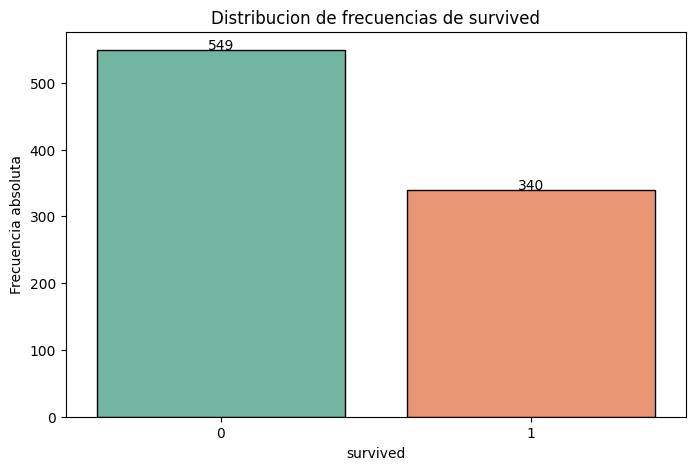

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\3421315680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


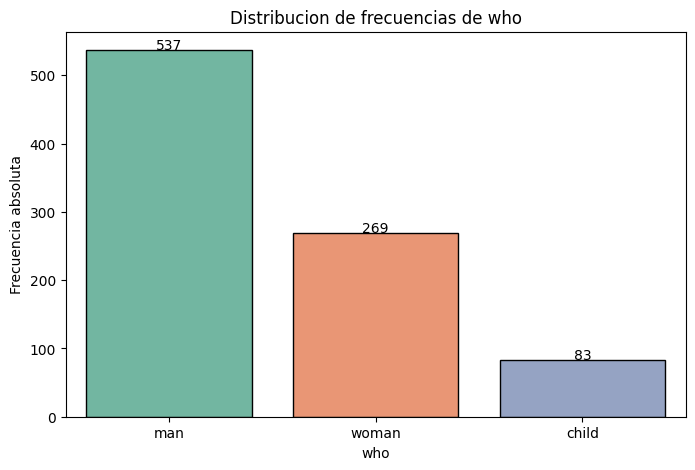

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\3421315680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


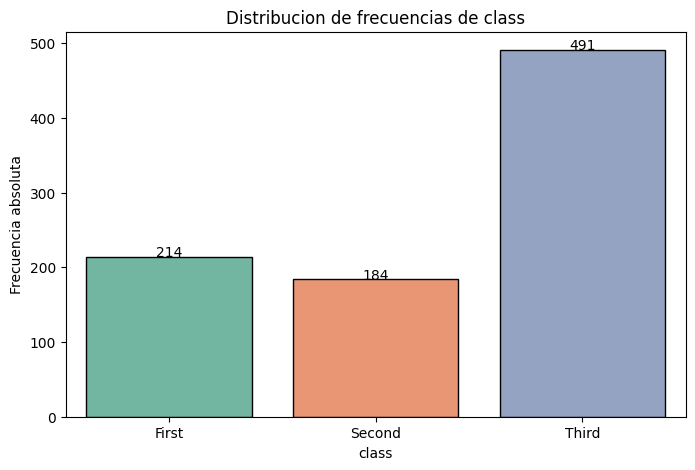

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\3421315680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


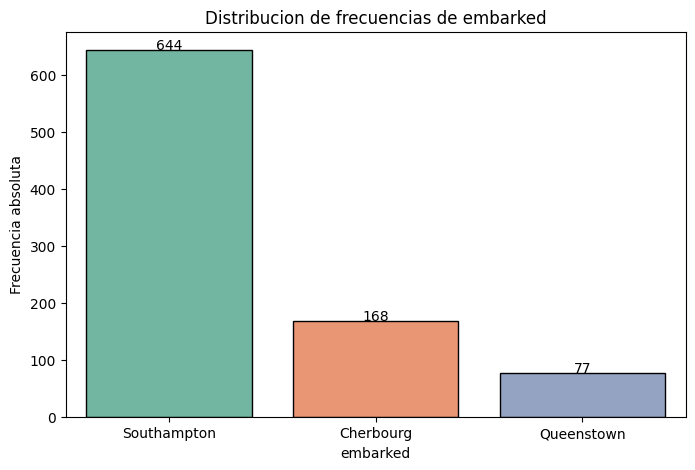

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\3421315680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


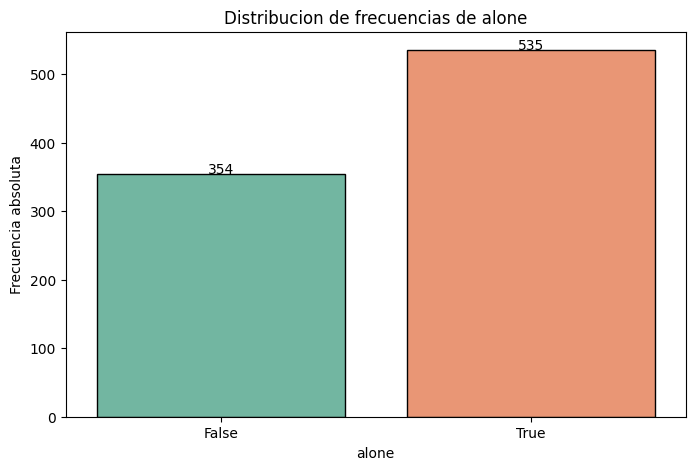

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\3421315680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


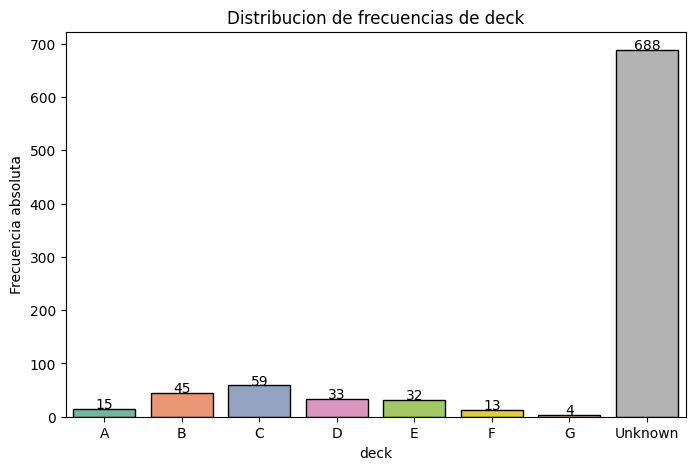

In [22]:
graficos_frecuencias(columnas_categoricas)

In [23]:
def graficos_porcentajes(lista_columnas):
    for col in lista_columnas:
        porcentajes = (df_titanic[col].value_counts(normalize=True) * 100).round(2)

        plt.figure(figsize=(8, 5))
        ax = sns.barplot(
            x=porcentajes.index,
            y=porcentajes.values,
            palette= "Set1",
            edgecolor="black"
        )

        for barra in ax.patches:
            altura = barra.get_height()
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                altura + 0.5,
                f"{altura:.2f}%",
                ha="center"
            )

        plt.title(f"Distribucion porcentual de {col}")
        plt.ylabel("Porcentaje (%)")
        plt.xlabel(col)
        plt.show()



C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\146629515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


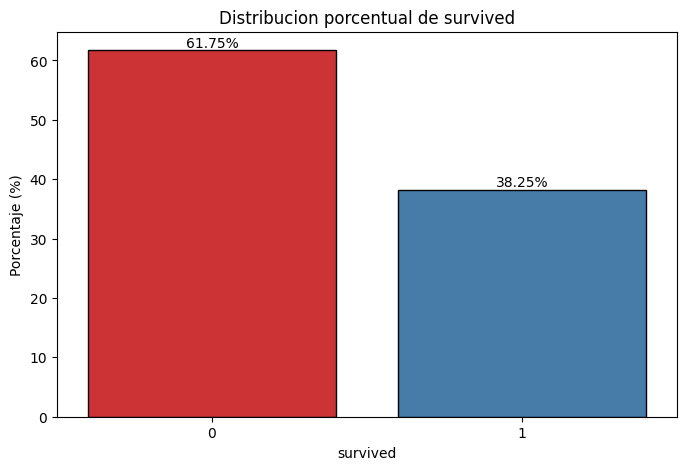

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\146629515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


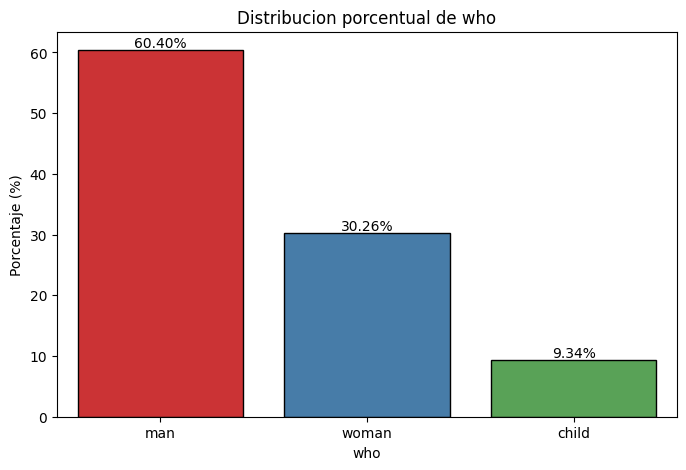

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\146629515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


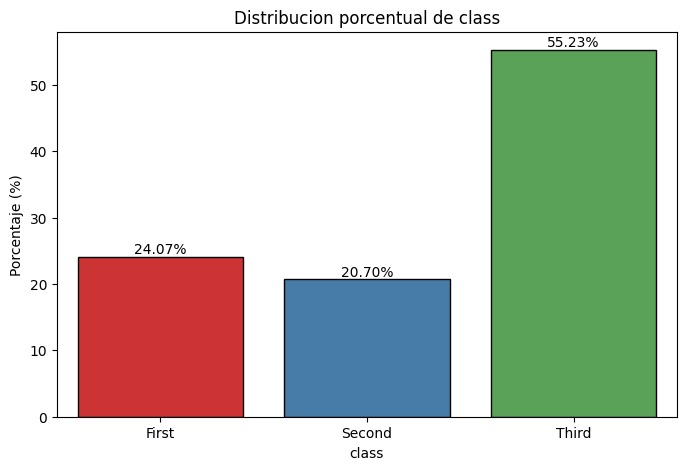

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\146629515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


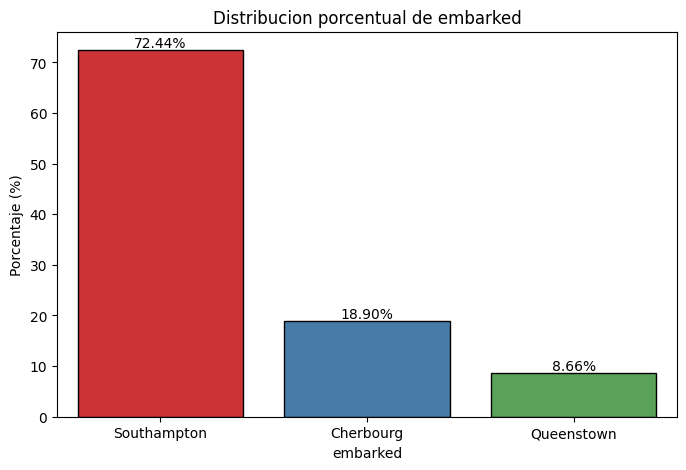

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\146629515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


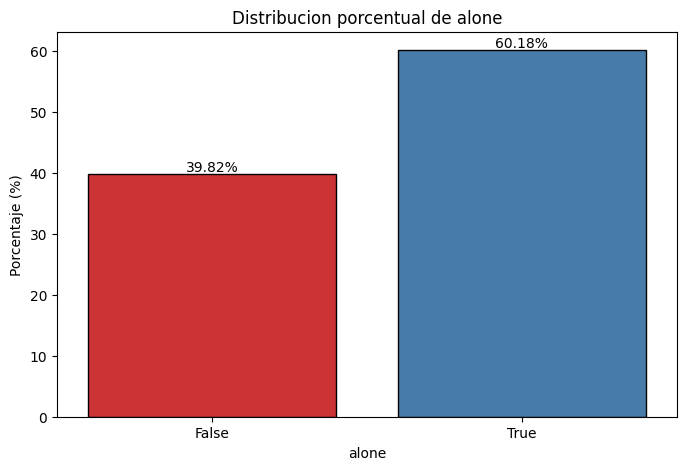

C:\Users\juan_\AppData\Local\Temp\ipykernel_4828\146629515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


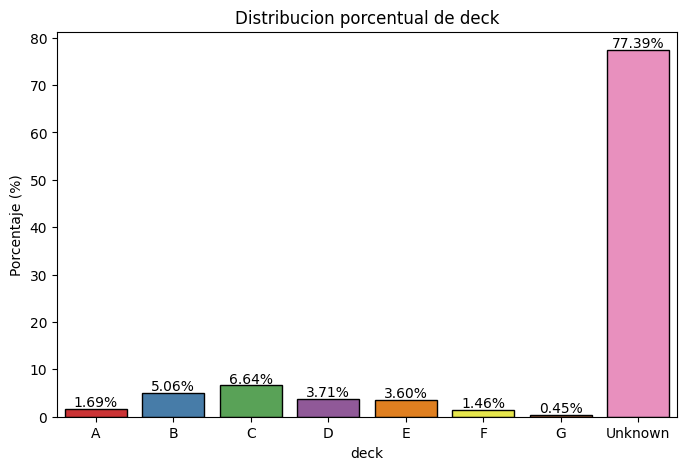

In [24]:
graficos_porcentajes(columnas_categoricas)

- En cuanto a los supervivientes, vemos que fueron menos que los fallecidos.
- También había más hombres que mujeres, y en menor medida, niños.
- Había más personas en tercera clase que en las demás, pero más en primera que en segunda.
- La mayoría de los pasajeros embarcaron en Southampton, un 18% lo hizo en Cherbourg, el otro 8% restante lo hizo en Queenstown.
- Entorno al 60% de los pasajeros viajaba solo, el resto lo hacía acompañado.
- En cuanto a la cubierta, como cabía esperar la mayoría no sabemos en cual estaba. Pero dejando de lado ese dato, vemos que se agrupaban principalmente entre la B, C, D, E, y en menor medida, en la A, F, G.

### #2.2 Numéricas

In [25]:
columnas_numericas = ["age", "sibsp", "fare"]

for col in columnas_numericas:
    print(f"\nVariable: {col}")
    print(df_titanic[col].describe().round(2))
    print(f"Mediana: {df_titanic[col].median()}")
    print(f"Moda: {df_titanic[col].mode().values}")


Variable: age
count    889.00
mean      29.55
std       13.17
min        0.42
25%       22.00
50%       27.00
75%       36.00
max       80.00
Name: age, dtype: float64
Mediana: 27.0
Moda: [27.]

Variable: sibsp
count    889.00
mean       0.52
std        1.10
min        0.00
25%        0.00
50%        0.00
75%        1.00
max        8.00
Name: sibsp, dtype: float64
Mediana: 0.0
Moda: [0]

Variable: fare
count    889.00
mean      32.10
std       49.70
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64
Mediana: 14.4542
Moda: [8.05]


In [26]:
def graficos_numericas(lista_columnas):
    for col in lista_columnas:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(
            data=df_titanic,
            x=col,
            kde=True,
            ax=axes[0],
            color="skyblue",
            edgecolor="black"
        )
        axes[0].set_title(f"Histograma y KDE de {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")

        sns.boxplot(
            data=df_titanic,
            x=col,
            ax=axes[1],
            color="lightgreen"
        )
        axes[1].set_title(f"Diagrama de caja de {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

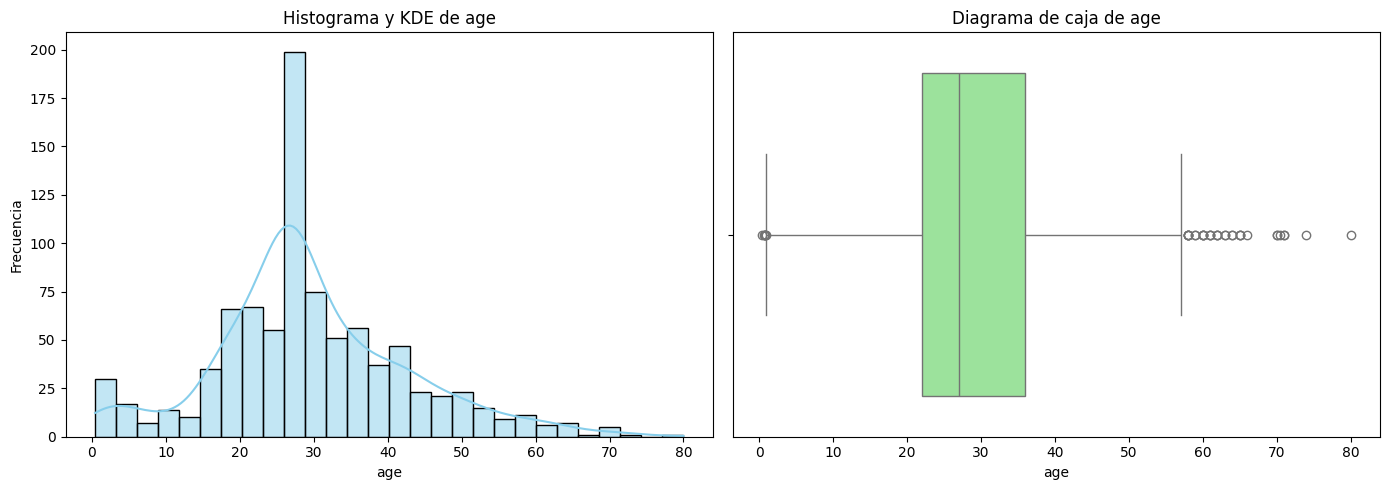

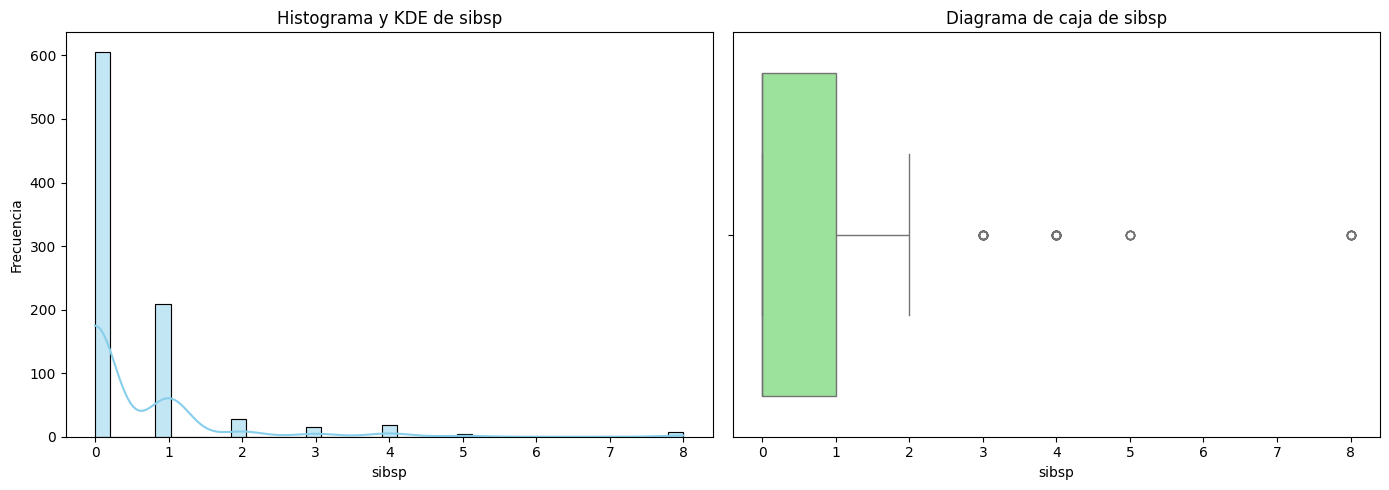

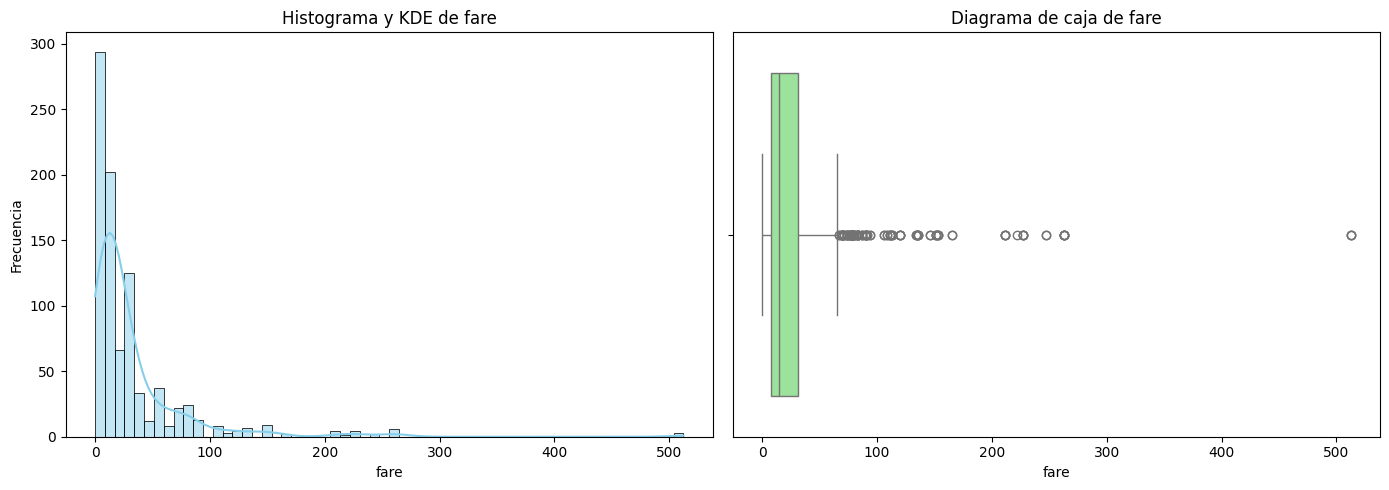

In [27]:
graficos_numericas(columnas_numericas)

- En cuanto a la edad. Encontramos el máximo en 80 años y el mínimo en un bebe de 5 meses. La media es de 29,55 años, pero la desviación estandar es alta (13.17), por lo que son más útiles en cuanto a información, la mediana y la moda, que coinciden en 27. Siendo alredor de este valor donde se agrupan la mayoría de los pasajeros, considerando valores extremos las edades avanzadas, como se observa en el boxplot.
- La variable sibsp muestra una fuerte concentración en 0, indicando que la mayoría de los pasajeros viajaban solos. La distribución está fuertemente sesgada a la derecha, con algunos casos de valores altos (hasta 8), que sí pueden considerarse atípicos.
- Para el precio que se pagó por el billete. De nuevo la información que nos puede prestar la media (32.10), se ve afectada por la desviación estandar, que es muy alta. Esto se debe a valores muy extremos, que representan precios mucho mayores que los que tuvieron la mayoría de los billete (moda = 8,05). Siendo el mínimo 0.00 y el máximo 512.33. La mediana en este caso tiene el valor de 14,4542